# *Lab DL / Project 4*

## import data

### Imports

In [33]:
import os
import random
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

### Seeds

In [34]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### conecting

In [35]:
# Google Drive is not needed in this version.
print('Using Colab local storage — Google Drive is not connected.')


Using Colab local storage — Google Drive is not connected.


### Dataset Path

In [36]:
import os

print(os.path.exists("/content/Currency.zip"))

True


In [37]:
print(os.listdir("/content"))

['.config', 'currency_data', 'currency_model_data', 'Currency.zip', 'sample_data']


In [38]:
from google.colab import files
import os
import shutil

# Upload Currency.zip directly from your computer
if not os.path.exists('/content/Currency.zip'):
    uploaded = files.upload()

print('Currency.zip is ready in Colab!')


Currency.zip is ready in Colab!


In [39]:
# Google Drive is not needed in this version.
print('Using Colab local storage — Google Drive is not connected.')


Using Colab local storage — Google Drive is not connected.


In [40]:
print(os.listdir('/content'))


['.config', 'currency_data', 'currency_model_data', 'Currency.zip', 'sample_data']


In [41]:
print(os.path.exists('/content/Currency.zip'))


True


In [42]:
zip_path = "/content/Currency.zip"

In [43]:
extract_path = "/content/currency_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [44]:
print(os.listdir(extract_path))

['Currency']


In [45]:
currency_path = "/content/currency_data/Currency"

print(os.listdir(currency_path))

['20 BD', '1BD', '0.05', '10 BD', '0.50', '0.100', '5 BD', '0.25', '0.5 BD']


In [46]:
for folder in os.listdir(currency_path):
    folder_path = os.path.join(currency_path, folder)

    print(folder, "->", os.listdir(folder_path)[:10])

20 BD -> ['bhd20_006.png', 'bhd20_015.png', 'bhd20_041.png', 'bhd20_030.png', 'bhd20_050.png', 'bhd20_039.png', 'bhd20_027.png', 'WhatsApp Image 2026-08-06 at 2.53.58 PM (1) - Copy.jpeg', 'WhatsApp Image 2026-08-06 at 2.54.01 PM (2).jpeg', 'bhd20_028.png']
1BD -> ['bhd1_042.png', 'WhatsApp Image 2026-08-06 at 4.28.44 PM (4).jpeg', 'WhatsApp Image 2026-08-06 at 2.53.54 PM (4).jpeg', 'bhd1_008.png', 'bhd1_044.png', 'bhd1_032.png', 'bhd1_041.png', 'WhatsApp Image 2026-08-06 at 4.28.44 PM (1).jpeg', 'bhd1_027.png', 'bhd1_045.png']
0.05 -> ['bahrain_5fils_29.jpg', 'bahrain_5fils_03.jpg', 'bahrain_5fils_19.jpg', 'bahrain_5fils_10.jpg', 'bahrain_5fils_15.jpg', 'bahrain_5fils_01.jpg', 'bahrain_5fils_44.jpg', 'bahrain_5fils_11.jpg', 'bahrain_5fils_12.jpg', 'bahrain_5fils_18.jpg']
10 BD -> ['bhd10_008.png', 'bhd10_045.png', 'bhd10_013.png', 'WhatsApp Image 2026-08-06 at 2.53.58 PM (3).jpeg', 'bhd10_010.png', 'bhd10_017.png', 'bhd10_016.png', 'WhatsApp Image 2026-08-06 at 2.53.59 PM (4) - Copy.jp

In [47]:
train_path = "/content/currency_data/Currency"
test_path = "/content/currency_data/Currency"

In [48]:
for folder in os.listdir(currency_path):
    train_folder = os.path.join(currency_path, folder)
    test_folder = os.path.join(currency_path, folder)

    train_images = len(os.listdir(train_folder))
    test_images = len(os.listdir(test_folder))

    print(folder, "-> Train:", train_images, "| Test:", test_images)

20 BD -> Train: 50 | Test: 50
1BD -> Train: 50 | Test: 50
0.05 -> Train: 50 | Test: 50
10 BD -> Train: 50 | Test: 50
0.50 -> Train: 50 | Test: 50
0.100 -> Train: 50 | Test: 50
5 BD -> Train: 50 | Test: 50
0.25 -> Train: 50 | Test: 50
0.5 BD -> Train: 50 | Test: 50


In [49]:
model_data_path = "/content/currency_model_data"

train_model_path = os.path.join(model_data_path, "Train")
test_model_path = os.path.join(model_data_path, "Test")

os.makedirs(train_model_path, exist_ok=True)
os.makedirs(test_model_path, exist_ok=True)

In [50]:
for folder in os.listdir(currency_path):

    original_train = os.path.join(currency_path, folder)
    original_test = os.path.join(currency_path, folder)

    new_train = os.path.join(train_model_path, folder)
    new_test = os.path.join(test_model_path, folder)

    os.makedirs(new_train, exist_ok=True)
    os.makedirs(new_test, exist_ok=True)

    for file in os.listdir(original_train):
        shutil.copy(
            os.path.join(original_train, file),
            os.path.join(new_train, file)
        )

    for file in os.listdir(original_test):
        shutil.copy(
            os.path.join(original_test, file),
            os.path.join(new_test, file)
        )

print("Dataset prepared successfully!")

Dataset prepared successfully!


In [51]:
print(os.listdir(train_model_path))
print(os.listdir(test_model_path))

['20 BD', '1BD', '0.05', '10 BD', '0.50', '0.100', '5 BD', '0.25', '0.5 BD']
['20 BD', '1BD', '0.05', '10 BD', '0.50', '0.100', '5 BD', '0.25', '0.5 BD']


In [52]:
train_datagen = ImageDataGenerator(
    rescale=1/255
)

test_datagen = ImageDataGenerator(
    rescale=1/255
)

In [53]:
train_generator = train_datagen.flow_from_directory(
    train_model_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 450 images belonging to 9 classes.


In [54]:
test_generator = test_datagen.flow_from_directory(
    test_model_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 450 images belonging to 9 classes.


In [55]:
# Preprocessing

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2)
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_model_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_model_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)
print("Number of classes:", len(class_names))


Found 450 images belonging to 9 classes.
Found 450 images belonging to 9 classes.
Classes: ['0.05', '0.100', '0.25', '0.5 BD', '0.50', '10 BD', '1BD', '20 BD', '5 BD']
Number of classes: 9


In [57]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

NameError: name 'model' is not defined

In [58]:
train_loss, train_accuracy = model.evaluate(train_generator)

print("Train Loss:", train_loss)
print("Train Accuracy:", train_accuracy)

NameError: name 'model' is not defined

## Model Training

In [59]:
# Step 1
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Step 2
model = Sequential()

model.add(Flatten(input_shape=(224, 224, 3)))  # image 3D -> 1D

model.add(Dense(500, activation='relu'))  # hidden layer
model.add(Dense(200, activation='relu'))  # hidden layer
model.add(Dense(100, activation='relu'))  # hidden layer

model.add(Dense(len(class_names), activation='softmax'))  # output layer


model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │    75,264,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           909 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,385,709 (287.57 MB)

 Trainable params: 75,385,709 (287.57 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# Step 3: Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [61]:
# Step 4: Fitting (Learning)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=50
)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.0933 - loss: 79.2723 - val_accuracy: 0.1089 - val_loss: 53.2662
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.1222 - loss: 30.4123 - val_accuracy: 0.1111 - val_loss: 35.0264
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.1311 - loss: 16.0699 - val_accuracy: 0.1089 - val_loss: 10.5779
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.1378 - loss: 10.0664 - val_accuracy: 0.1444 - val_loss: 9.5074
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.1111 - loss: 9.2300 - val_accuracy: 0.1600 - val_loss: 8.7002
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.1467 - loss: 7.1716 - val_accuracy: 0.1289 - val_loss: 7.2304
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.1733 - loss: 5.8353 - val_accuracy: 0.1467 - val_loss: 3.4211
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.2400 - loss: 3.7741 - val_accuracy: 0.2311 - va

In [62]:
# history
history_df = pd.DataFrame(history.history)
history_df


,accuracy,loss,val_accuracy,val_loss
0,0.093333,79.272263,0.108889,53.266163
1,0.122222,30.412300,0.111111,35.026440
2,0.131111,16.069927,0.108889,10.577929
3,0.137778,10.066420,0.144444,9.507392
4,0.111111,9.229995,0.160000,8.700192
5,0.146667,7.171556,0.128889,7.230373
6,0.173333,5.835342,0.146667,3.421054
7,0.240000,3.774077,0.231111,2.856113
8,0.188889,3.661897,0.208889,4.392597
9,0.195556,3.427721,0.271111,2.789512


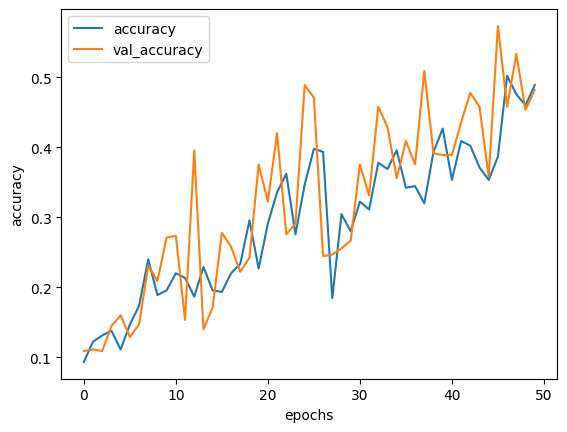

In [63]:
history_df[['accuracy', 'val_accuracy']].plot()
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.show()


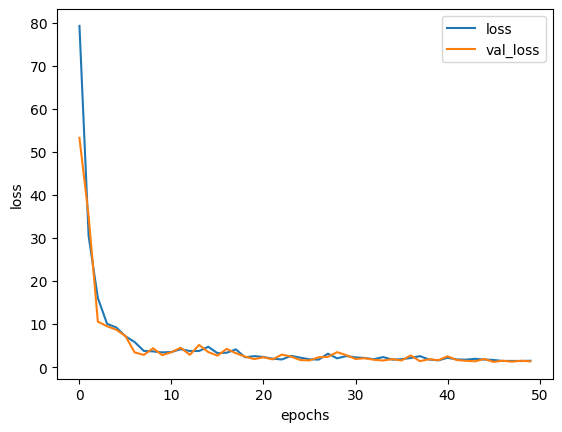

In [64]:
history_df[["loss", "val_loss"]].plot()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()


## Evaluation

In [65]:
# Step 5: Prediction

test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_label = np.argmax(y_pred, axis=1)
y_test = test_generator.classes

print("Accuracy:", accuracy_score(y_test, y_pred_label))


15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 462ms/step
Accuracy: 0.4822222222222222


In [66]:
model.evaluate(test_generator)


15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 448ms/step - accuracy: 0.4822 - loss: 1.3386


[1.3386000394821167, 0.48222222924232483]

In [67]:
print(classification_report(
    y_test,
    y_pred_label,
    target_names=class_names
))


              precision    recall  f1-score   support

        0.05       0.83      0.50      0.62        50
       0.100       0.82      0.28      0.42        50
        0.25       0.00      0.00      0.00        50
      0.5 BD       0.27      0.88      0.42        50
        0.50       0.32      0.52      0.40        50
       10 BD       0.92      0.46      0.61        50
         1BD       0.39      0.36      0.38        50
       20 BD       0.67      0.36      0.47        50
        5 BD       0.78      0.98      0.87        50

    accuracy                           0.48       450
   macro avg       0.56      0.48      0.46       450
weighted avg       0.56      0.48      0.46       450



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
conf_matrix = confusion_matrix(y_test, y_pred_label)
conf_matrix


array([[25,  0,  0,  7,  9,  0,  2,  3,  4],
       [ 0, 14,  0, 23, 13,  0,  0,  0,  0],
       [ 5,  0,  0, 14, 22,  0,  8,  1,  0],
       [ 0,  0,  0, 44,  1,  0,  4,  1,  0],
       [ 0,  3,  0, 12, 26,  0,  7,  2,  0],
       [ 0,  0,  0, 16,  6, 23,  2,  1,  2],
       [ 0,  0,  0, 27,  4,  0, 18,  1,  0],
       [ 0,  0,  0, 17,  0,  2,  5, 18,  8],
       [ 0,  0,  0,  1,  0,  0,  0,  0, 49]])

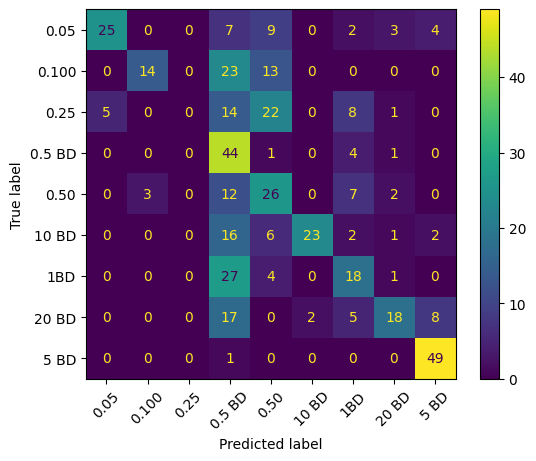

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_label,
    display_labels=class_names,
    xticks_rotation=45
)
plt.show()


## Error Analysis

In [70]:
idx = np.where(y_test != y_pred_label)[0]
print("Number of wrong predictions:", len(idx))
idx[:25]


Number of wrong predictions: 233


array([ 0,  1,  3,  7,  9, 10, 12, 13, 14, 15, 18, 20, 22, 23, 24, 27, 28,
       33, 36, 37, 39, 41, 44, 47, 48])

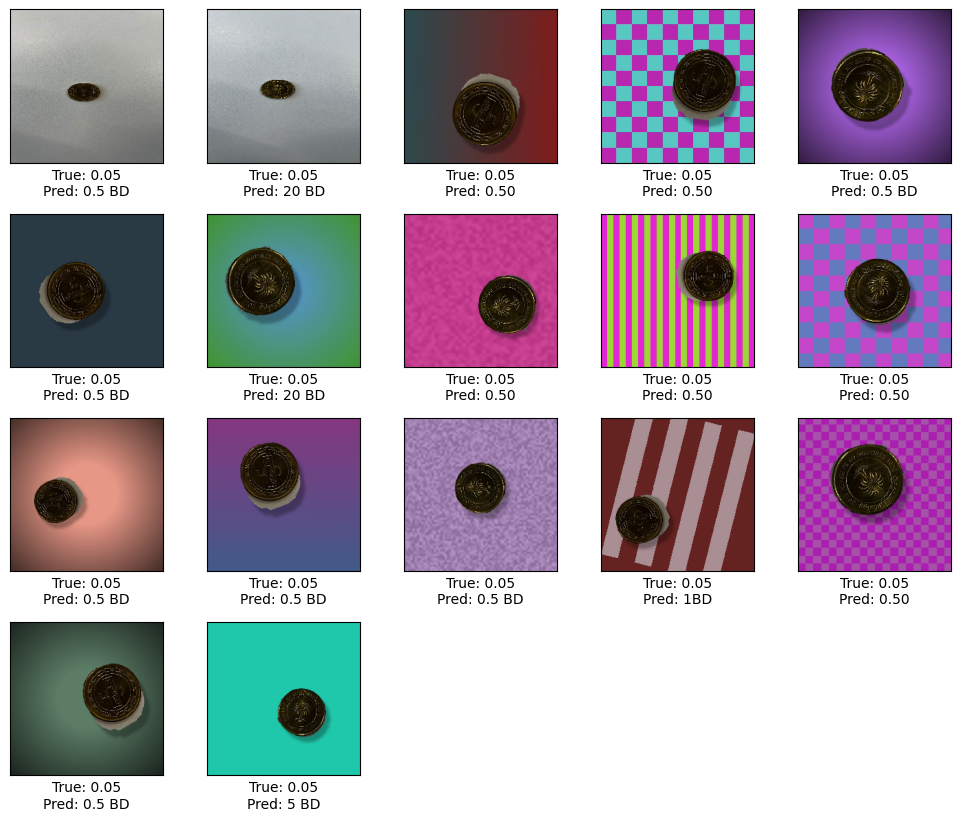

In [71]:
# Show some images the model got wrong

test_generator.reset()
images, labels = next(test_generator)

plt.figure(figsize=(10, 10))

shown = 0
for i in range(len(images)):
    if y_test[i] != y_pred_label[i]:
        plt.subplot(5, 5, shown + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i])
        plt.xlabel(
            f"True: {class_names[y_test[i]]}\n"
            f"Pred: {class_names[y_pred_label[i]]}"
        )
        shown += 1
        if shown == 25:
            break

plt.tight_layout()
plt.show()


## Key Questions

In [72]:
print("Most confused classes can be seen in the confusion matrix above.")
print("Similar-looking notes can be checked from the misclassified images.")
print("Background effects can be checked using new images with unseen backgrounds.")


Most confused classes can be seen in the confusion matrix above.
Similar-looking notes can be checked from the misclassified images.
Background effects can be checked using new images with unseen backgrounds.


## Streamlit Deployment + API

In [73]:
model.save("currency_model.keras")

In [74]:
from google.colab import files

files.download('/content/currency_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
# Save the trained model

model.save("/content/currency_model.keras")
print("Model saved successfully!")


Model saved successfully!


In [76]:
# Create Streamlit app

app_code = '''
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf

model = tf.keras.models.load_model("currency_model.keras")

class_names = %r

st.title("Bahraini Currency Recognition")

uploaded_file = st.file_uploader("Upload a currency image", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_container_width=True)

    image = image.resize((224, 224))
    image_array = np.array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array)
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class]

    st.write("Prediction:", class_names[predicted_class])
    st.write("Confidence:", float(confidence))
''' % class_names

with open("/content/app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")


app.py created successfully!


## Final Reflection

1. Why did classification work well initially?
2. What problems did object detection solve?
3. Which approach is more suitable for real-world deployment?
4. How would you improve the system further?


## Notes

The dataset used in this notebook contains 9 currency classes. The model output layer therefore uses the number of classes detected from the dataset.
